In [229]:
# Imports
import pandas as pd
import numpy as np
import os
from functools import reduce
# plotting the distribution of the number of admissions per patient
import matplotlib.pyplot as plt
import seaborn as sns


In [230]:
# Importing DB...
BASE_DB = "mimic-iv-clinical-database-demo-2.2"
HOSP_PATH = os.path.join(BASE_DB, "hosp")
ICU_PATH = os.path.join(BASE_DB, "icu")

# Loading Tables...
patients = pd.read_csv(f'{HOSP_PATH}/patients.csv.gz')
admissions = pd.read_csv(f'{HOSP_PATH}/admissions.csv.gz')
lab_events = pd.read_csv(f'{HOSP_PATH}/labevents.csv.gz')
lab_items = pd.read_csv(f'{HOSP_PATH}/d_labitems.csv.gz')

chart_events = pd.read_csv(f'{ICU_PATH}/chartevents.csv.gz')
icu_stays = pd.read_csv(f'{ICU_PATH}/icustays.csv.gz')
d_items = pd.read_csv(f'{ICU_PATH}/d_items.csv.gz') 



# Step 1 : Data Exploring

In [231]:
# exploring the different tables to then proceed to data cleaning and preprocessing
print("Patients:")
print(patients.head())
print("Admissions:")
print(admissions.head())
print("Lab Events:")
print(lab_events.head())
print("Lab Items:")
print(lab_items.head())
print("Chart Events:")
print(chart_events.head())
print("ICU Stays:") 
print(icu_stays.head())
print("D Items:")
print(d_items.head())


Patients:
   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10014729      F          21         2125       2011 - 2013         NaN
1    10003400      F          72         2134       2011 - 2013  2137-09-02
2    10002428      F          80         2155       2011 - 2013         NaN
3    10032725      F          38         2143       2011 - 2013  2143-03-30
4    10027445      F          48         2142       2011 - 2013  2146-02-09
Admissions:
   subject_id   hadm_id            admittime            dischtime  \
0    10004235  24181354  2196-02-24 14:38:00  2196-03-04 14:02:00   
1    10009628  25926192  2153-09-17 17:08:00  2153-09-25 13:20:00   
2    10018081  23983182  2134-08-18 02:02:00  2134-08-23 19:35:00   
3    10006053  22942076  2111-11-13 23:39:00  2111-11-15 17:20:00   
4    10031404  21606243  2113-08-04 18:46:00  2113-08-06 20:57:00   

             deathtime admission_type admit_provider_id  \
0                  NaN         URGENT           

In [232]:
# showing the number of rows and columns in each table
print("Patients shape:", patients.shape) # understanding the size of the data (based on how many patients we have)
print("Admissions shape:", admissions.shape) 
print("ICU Stays shape:", icu_stays.shape)
print("Chart Events shape:", chart_events.shape)
print("Chart Items shape:", d_items.shape)
print("Lab Events shape:", lab_events.shape)
print("Lab Items shape:", lab_items.shape)

Patients shape: (100, 6)
Admissions shape: (275, 16)
ICU Stays shape: (140, 8)
Chart Events shape: (668862, 11)
Chart Items shape: (4014, 9)
Lab Events shape: (107727, 16)
Lab Items shape: (1622, 4)


In [233]:
# exploring the data types and information about each table
print("------------------------------------------------------")
print("Patients info:")
print("------------------------------------------------------")
patients.info()

print("\n------------------------------------------------------")
print("Admissions info:")
print("------------------------------------------------------")
admissions.info()

print("\n------------------------------------------------------")
print("Chart Events info:")
print("------------------------------------------------------")
chart_events.info()

print("\n------------------------------------------------------")
print("Chart Items info:")
print("------------------------------------------------------")
d_items.info()

print("\n------------------------------------------------------")
print("Lab Events info:")
print("------------------------------------------------------")
lab_events.info()

print("\n------------------------------------------------------")
print("Lab Items info:")
print("------------------------------------------------------")
lab_items.info()


print("\n------------------------------------------------------")
print("ICU Stays info:")
print("------------------------------------------------------")
icu_stays.info()


------------------------------------------------------
Patients info:
------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subject_id         100 non-null    int64
 1   gender             100 non-null    str  
 2   anchor_age         100 non-null    int64
 3   anchor_year        100 non-null    int64
 4   anchor_year_group  100 non-null    str  
 5   dod                31 non-null     str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB

------------------------------------------------------
Admissions info:
------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   subject_id            275 non-null    int64


In [234]:
# finding duplicate values in each table
print("------------------------------------------------------")
print("Duplicates in Patients:")   
print("------------------------------------------------------")
print(patients.duplicated().sum())  # number of duplicate rows in each column

print("\n------------------------------------------------------")
print("Duplicates in Admissions:")
print("------------------------------------------------------")
print(admissions.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in ICU Stays:")
print("------------------------------------------------------")
print(icu_stays.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Chart Events:")
print("------------------------------------------------------")
print(chart_events.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Chart Items:")
print("------------------------------------------------------")
print(d_items.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Lab Events:")
print("------------------------------------------------------")
print(lab_events.duplicated().sum()) 

print("\n------------------------------------------------------")
print("Duplicates in Lab Items:")
print("------------------------------------------------------")
print(lab_items.duplicated().sum()) 


------------------------------------------------------
Duplicates in Patients:
------------------------------------------------------
0

------------------------------------------------------
Duplicates in Admissions:
------------------------------------------------------
0

------------------------------------------------------
Duplicates in ICU Stays:
------------------------------------------------------
0

------------------------------------------------------
Duplicates in Chart Events:
------------------------------------------------------
0

------------------------------------------------------
Duplicates in Chart Items:
------------------------------------------------------
0

------------------------------------------------------
Duplicates in Lab Events:
------------------------------------------------------
0

------------------------------------------------------
Duplicates in Lab Items:
------------------------------------------------------
0


In [235]:
# extracting unique values from each table to understand the data better
# to understand how to transform the data and to find out if there are any categorical variables (string) that can be encoded
print("------------------------------------------------------")
print("Unique values in Patients:")
print("------------------------------------------------------")
# print unique values in each column of patients table where dtype is string
for col in patients.columns:
    if patients[col].dtype == 'str':
        print(f"*** {col}: {patients[col].unique()} \n")

print("\n------------------------------------------------------")
print("Unique values in Admissions:")
print("------------------------------------------------------")
for col in admissions.columns:
    if admissions[col].dtype == 'str':
        print(f"*** {col}: {admissions[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in ICU Stays:")
print("------------------------------------------------------")
for col in icu_stays.columns:
    if icu_stays[col].dtype == 'str':
        print(f"*** {col}: {icu_stays[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in Chart Events:")
print("------------------------------------------------------")
for col in chart_events.columns:
    if chart_events[col].dtype == 'str':
        print(f"*** {col}: {chart_events[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in Chart Items:")
print("------------------------------------------------------")
for col in d_items.columns:
    if d_items[col].dtype == 'str':
        print(f"*** {col}: {d_items[col].unique()}\n")

print("\n------------------------------------------------------")
print("Unique values in Lab Events:")
print("------------------------------------------------------")
for col in lab_events.columns:
    if lab_events[col].dtype == 'str':
        print(f"*** {col}: {lab_events[col].unique()}\n")
        
print("\n------------------------------------------------------")
print("Unique values in Lab Items:")
print("------------------------------------------------------")
for col in lab_items.columns:
    if lab_items[col].dtype == 'str':
        print(f"*** {col}: {lab_items[col].unique()}\n")


------------------------------------------------------
Unique values in Patients:
------------------------------------------------------
*** gender: <StringArray>
['F', 'M']
Length: 2, dtype: str 

*** anchor_year_group: <StringArray>
['2011 - 2013', '2014 - 2016']
Length: 2, dtype: str 

*** dod: <StringArray>
[         nan, '2137-09-02', '2143-03-30', '2146-02-09', '2148-02-07',
 '2154-02-04', '2155-12-03', '2201-12-24', '2155-12-07', '2137-10-31',
 '2180-09-09', '2115-10-12', '2116-03-12', '2117-06-26', '2172-04-19',
 '2137-10-09', '2116-07-05', '2182-10-16', '2201-07-13', '2175-07-20',
 '2134-10-28', '2185-01-22', '2186-11-17', '2117-03-24', '2146-07-12',
 '2184-11-22', '2131-04-28', '2149-11-21', '2187-04-29', '2135-01-19',
 '2177-03-29', '2111-11-15']
Length: 32, dtype: str 


------------------------------------------------------
Unique values in Admissions:
------------------------------------------------------
*** admittime: <StringArray>
['2196-02-24 14:38:00', '2153-09-17 17

In [236]:
# finding missing values in each table
# by defining the percentage of missing values in each column
print("------------------------------------------------------")
print("Missing values in Patients:")   
print("------------------------------------------------------")
print(patients.isnull().sum()/patients.shape[0]*100)  

print("\n------------------------------------------------------")
print("Missing values in Admissions:")
print("------------------------------------------------------")
print(admissions.isnull().sum()/admissions.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in ICU Stays:")
print("------------------------------------------------------")
print(icu_stays.isnull().sum()/icu_stays.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Chart Events:")
print("------------------------------------------------------")
print(chart_events.isnull().sum()/chart_events.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Chart Items:")
print("------------------------------------------------------")
print(d_items.isnull().sum()/d_items.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Lab Events:")
print("------------------------------------------------------")
print(lab_events.isnull().sum()/lab_events.shape[0]*100) 

print("\n------------------------------------------------------")
print("Missing values in Lab Items:")
print("------------------------------------------------------")
print(lab_items.isnull().sum()/lab_items.shape[0]*100) 


------------------------------------------------------
Missing values in Patients:
------------------------------------------------------
subject_id            0.0
gender                0.0
anchor_age            0.0
anchor_year           0.0
anchor_year_group     0.0
dod                  69.0
dtype: float64

------------------------------------------------------
Missing values in Admissions:
------------------------------------------------------
subject_id               0.000000
hadm_id                  0.000000
admittime                0.000000
dischtime                0.000000
deathtime               94.545455
admission_type           0.000000
admit_provider_id        0.000000
admission_location       0.000000
discharge_location      15.272727
insurance                0.000000
language                 0.000000
marital_status           4.363636
race                     0.000000
edregtime               33.818182
edouttime               33.818182
hospital_expire_flag     0.000000
dtype:

subject_id       0.000000
hadm_id          0.000000
stay_id          0.000000
caregiver_id     3.624066
charttime        0.000000
storetime        0.173279
itemid           0.000000
value            3.099294
valuenum        61.505662
valueuom        75.694388
warning          0.173279
dtype: float64

------------------------------------------------------
Missing values in Chart Items:
------------------------------------------------------
itemid              0.000000
label               0.000000
abbreviation        0.000000
linksto             0.000000
category            0.000000
unitname           72.396612
param_type          0.000000
lownormalvalue     99.526657
highnormalvalue    99.451918
dtype: float64

------------------------------------------------------
Missing values in Lab Events:
------------------------------------------------------
labevent_id           0.000000
subject_id            0.000000
hadm_id              26.381501
specimen_id           0.000000
itemid          

------------------ Number of admissions per patient: ------------------
   subject_id  n_admissions
0    10000032             4
1    10001217             2
2    10001725             1
3    10002428             7
4    10002495             1

------------------ Number of ICU stays per patient: ------------------
   subject_id  n_icu_stays
0    10000032            1
1    10001217            2
2    10001725            1
3    10002428            4
4    10002495            1


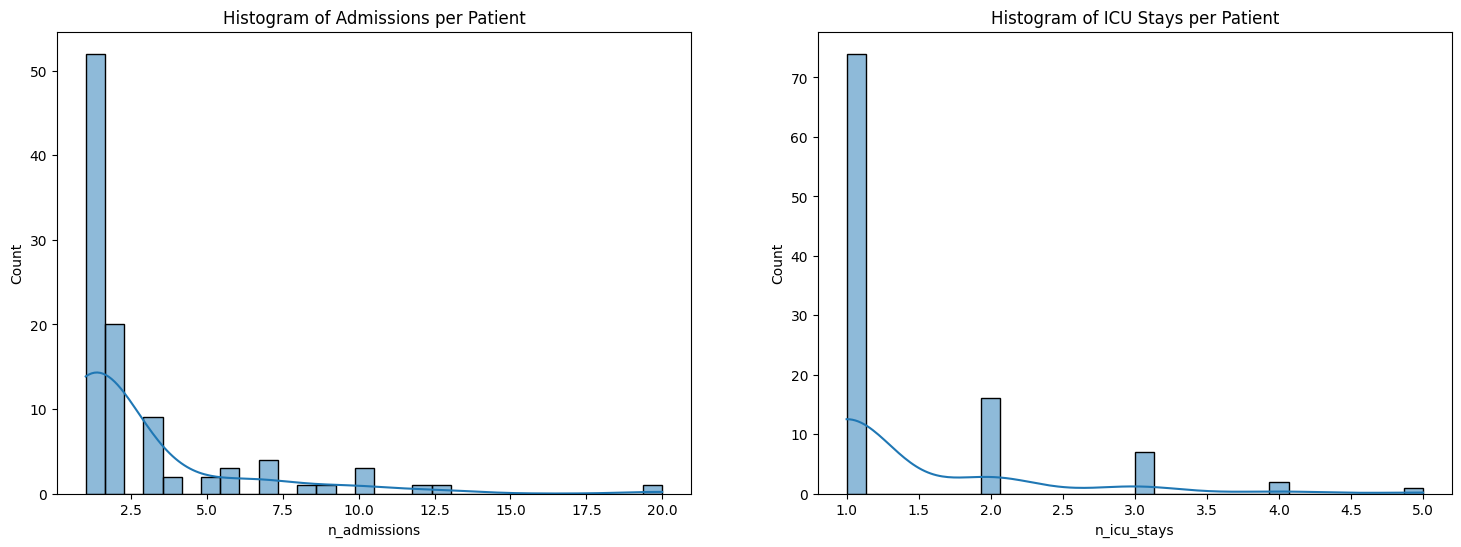

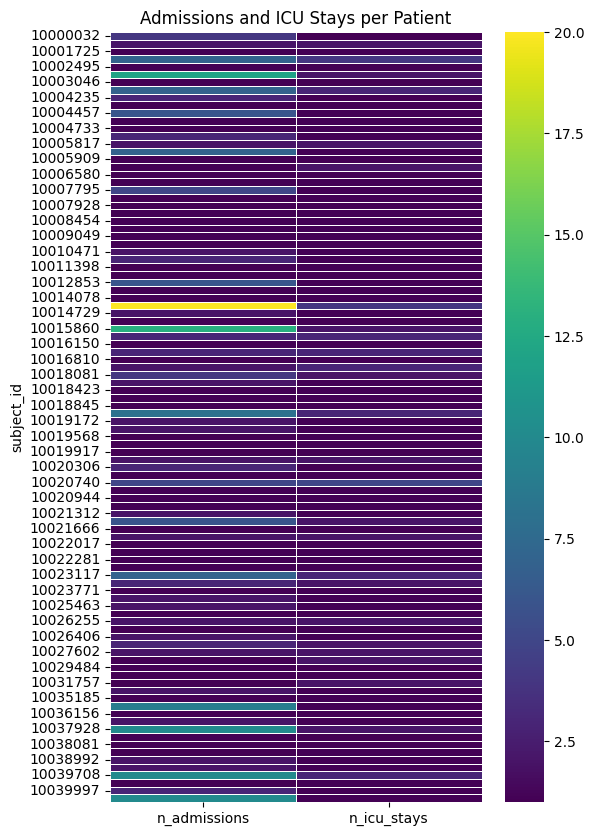

In [237]:
# counting the number of unique admissions and ICU stays for each patient
print("------------------ Number of admissions per patient: ------------------") 
admissions_per_patient = admissions.groupby("subject_id")["hadm_id"].nunique()
admissions_per_patient = admissions_per_patient.reset_index()
admissions_per_patient.columns = ["subject_id", "n_admissions"]
print(admissions_per_patient.head())

print("\n------------------ Number of ICU stays per patient: ------------------")
icu_stays_per_patient = icu_stays.groupby("subject_id")["stay_id"].nunique()
icu_stays_per_patient = icu_stays_per_patient.reset_index()
icu_stays_per_patient.columns = ["subject_id", "n_icu_stays"]
print(icu_stays_per_patient.head())

# Displaying the distribution of the number of admissions and ICU stays per patient 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(admissions_per_patient['n_admissions'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Histogram of Admissions per Patient')

sns.histplot(icu_stays_per_patient['n_icu_stays'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Histogram of ICU Stays per Patient')
plt.show()

# creating a heatmap to show the number of admissions and ICU stays per patient
patient_summary = admissions_per_patient.merge(
    icu_stays_per_patient,
    on="subject_id",
    how="outer"
).fillna(0)
plt.figure(figsize=(6,10))

sns.heatmap(
    patient_summary.set_index("subject_id"),
    cmap="viridis",
    linewidths=0.5
)
plt.title("Admissions and ICU Stays per Patient")
plt.show()


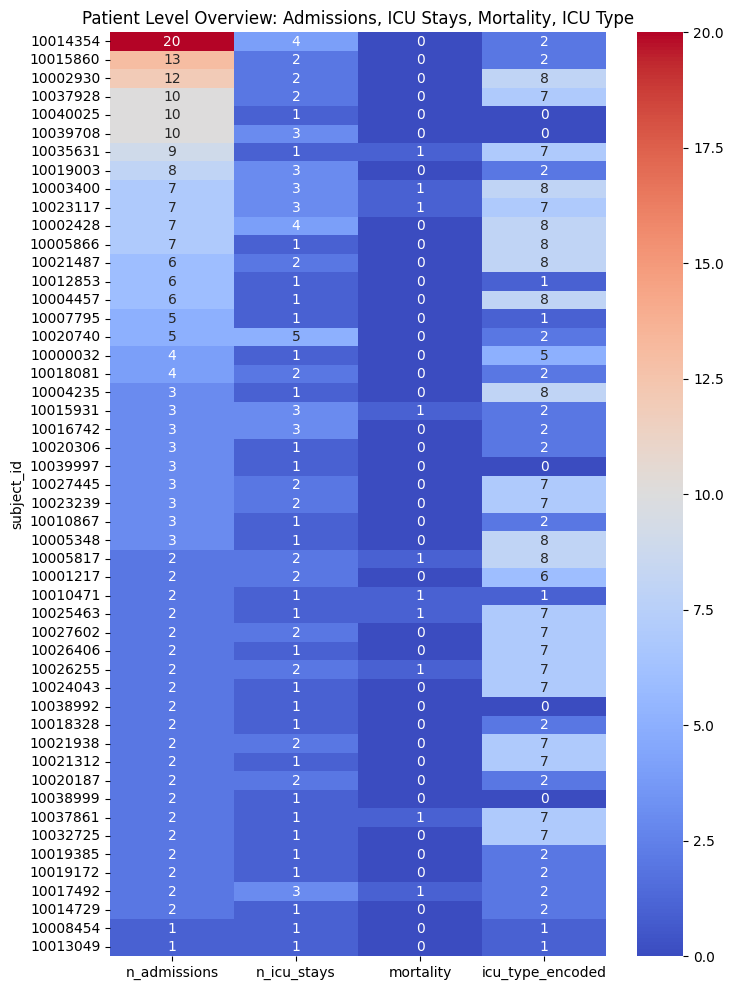

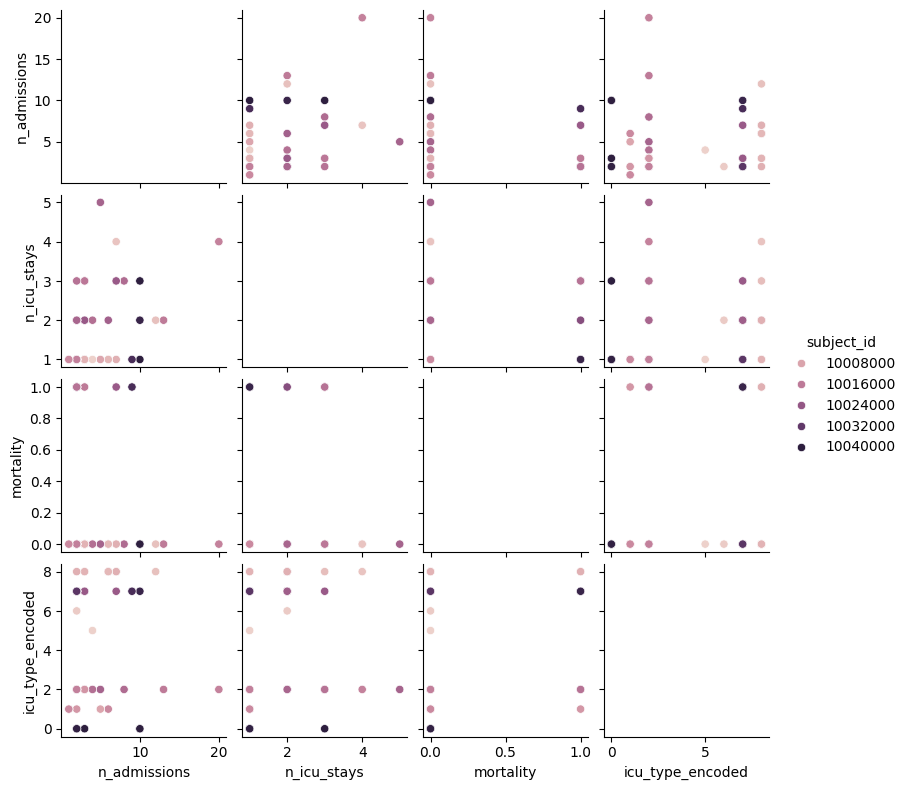

In [ ]:
# Display heatmap to show the mortality rate of patients based on the number of admissions, ICU stays and type of ICU stay
# This will help us undertand better the correlation between these different variables
mortality = admissions.groupby("subject_id")["hospital_expire_flag"].max().reset_index()
mortality.columns = ["subject_id", "mortality"]
icu_type = icu_stays.groupby("subject_id")["first_careunit"].first().reset_index()
patient_summary = patient_summary.merge(mortality, on="subject_id", how="left")
patient_summary = patient_summary.merge(icu_type, on="subject_id", how="left").fillna("Unknown")

patient_summary["icu_type_encoded"] = icu_stays["first_careunit"].astype("category").cat.codes
# PRINT WHEN NEEEDED - to understand the mapping of the encoded values to the original ICU types
icu_mapping = dict(enumerate(icu_stays["first_careunit"].astype("category").cat.categories))

plt.figure(figsize=(8,12))

heatmap_df = patient_summary[[
    "subject_id",
    "n_admissions",
    "n_icu_stays",
    "mortality",
    "icu_type_encoded"
]]


heatmap_df = heatmap_df.sort_values("n_admissions", ascending=False).head(50)
sns.heatmap(
    heatmap_df.set_index("subject_id"),
    cmap="coolwarm",
    annot=True,
    fmt=".0f"
)

plt.title("Patient Level Overview: Admissions, ICU Stays, Mortality, ICU Type")
plt.show()


In [239]:
#Charevents table: understanding clinical variables
# each itemid represents the SAME clinical measurements in the ICU system (heart rate, blood pressure, respiratory rate, oxygen saturation)
# For example: the heart rate measurements could be mapped to multiple item_ids (for the same patient & icu stay)
df_vitals = chart_events[
    (chart_events["valueuom"].str.lower() == "bpm") &
    (chart_events["stay_id"] == 32604416)
]
df_unique_itemids = df_vitals.drop_duplicates(subset=["itemid"])
print(df_unique_itemids[["subject_id","stay_id","itemid","value" ,"valuenum", "valueuom"]].head())


    subject_id   stay_id  itemid value  valuenum valueuom
5     10005817  32604416  224751    52      52.0      bpm
11    10005817  32604416  220047    55      55.0      bpm
36    10005817  32604416  220046   120     120.0      bpm
69    10005817  32604416  220045    80      80.0      bpm


# Step 2 : Data Cleaning

Handling missing values

In [240]:
# ** The patients table: "dod" (date of death ) -> 69% missing, is not relevant since we will use the variable "hospital_expire_flag" to determine if the patient died during the hospital stay or not, so we can ignore the missing values in the "dod" column.
# ** The admssion table: "deathtime" -> 94% missing, not relevant since will use "hospital_expire_flag" 
# ** The ICU stays table: no missing data x)
# ** The chart events table: valuenom -> 26% missing | the columns "value" and "valuenum" are mutually exclusive, meaning they contain the same information in different formats "value" in string format and "valuenum" in numeric format.
#  For our analysis we will need the numeric format, so we will use the "valuenum" column 
# "valueom" column has 36% missing data, will be handled later if needed, --IGNORE--
chart_events = chart_events[chart_events["valuenum"].notna()]
chart_events.info()

<class 'pandas.DataFrame'>
Index: 257474 entries, 1 to 668825
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   subject_id    257474 non-null  int64  
 1   hadm_id       257474 non-null  int64  
 2   stay_id       257474 non-null  int64  
 3   caregiver_id  233234 non-null  float64
 4   charttime     257474 non-null  str    
 5   storetime     257474 non-null  str    
 6   itemid        257474 non-null  int64  
 7   value         255066 non-null  str    
 8   valuenum      257474 non-null  float64
 9   valueuom      162571 non-null  str    
 10  warning       257474 non-null  float64
dtypes: float64(3), int64(4), str(4)
memory usage: 23.6 MB


In [241]:
# ** the chart items table: "unitname" -> 72% missing, not relevant will use label to identify chart items found in chart events
# ** the lab events table: "valuenum" contains 9% missing
print("------------ labs events with missing values in valuenum ------------")
lab_events[lab_events['valuenum'].isnull()]
# we are going to drop the rows with missing data since it represents a small percentage of the data and we can't use filling methods to impute the missing values in the "valuenum" column since we don't have enough information to fill the missing data with a specific value (mean, median, mode) without introducing bias to the data.
lab_events = lab_events[lab_events['valuenum'].notna()]
lab_events.info()

------------ labs events with missing values in valuenum ------------
<class 'pandas.DataFrame'>
Index: 95246 entries, 0 to 107725
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   labevent_id        95246 non-null  int64  
 1   subject_id         95246 non-null  int64  
 2   hadm_id            71906 non-null  float64
 3   specimen_id        95246 non-null  int64  
 4   itemid             95246 non-null  int64  
 5   order_provider_id  14246 non-null  str    
 6   charttime          95246 non-null  str    
 7   storetime          95237 non-null  str    
 8   value              95246 non-null  str    
 9   valuenum           95246 non-null  float64
 10  valueuom           89270 non-null  str    
 11  ref_range_lower    87905 non-null  float64
 12  ref_range_upper    87905 non-null  float64
 13  flag               38906 non-null  str    
 14  priority           87466 non-null  str    
 15  comments       

In [242]:
# the lab items table: the column "label" contains 0.18% missing values
print("------------ lab items with missing values in label ------------")
null_labs_label = lab_items[lab_items['label'].isna()]["itemid"].unique()
print(null_labs_label)
# drop rows with missing labels since we can't use them to identify the lab items
lab_items = lab_items[~lab_items['label'].isin(null_labs_label)]
lab_events = lab_events[lab_events['itemid'].isin(lab_items['itemid'])]  # keep only lab events with valid itemids in lab items table
print(" \n------------ lab items info after dropping rows with missing labels ------------")
lab_items.info()

------------ lab items with missing values in label ------------
[51771 51955 52374]
 
------------ lab items info after dropping rows with missing labels ------------
<class 'pandas.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   itemid    1622 non-null   int64
 1   label     1619 non-null   str  
 2   fluid     1622 non-null   str  
 3   category  1622 non-null   str  
dtypes: int64(1), str(3)
memory usage: 50.8 KB


# Step 3 : Variables Extraction | Feature Definition

In [243]:
#convert to datetime
icu_stays['intime'] = pd.to_datetime(icu_stays['intime'])
icu_stays['outtime'] = pd.to_datetime(icu_stays['outtime'])

# Select first ICU stay per patient
icu_stays = icu_stays.sort_values(by="intime")
icu_stay_first = icu_stays.groupby("subject_id").first()

# add the patients' demographics based on the chosen icu stay
df = icu_stay_first.merge(patients, on="subject_id")

# add relevant hospital admission
df = df.merge(admissions, on=["subject_id", "hadm_id"])

# Keep relevant columns
df = df[[
     "subject_id","hadm_id", 
     "stay_id", "first_careunit",
     "anchor_age", "gender",
     "admission_type", "hospital_expire_flag",
     "intime", "outtime"
]]
df.head()



,subject_id,hadm_id,stay_id,first_careunit,anchor_age,gender,admission_type,hospital_expire_flag,intime,outtime
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),52,F,EW EMER.,0,2180-07-23 14:00:00,2180-07-23 23:50:47
1,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),55,F,EW EMER.,0,2157-11-20 19:18:02,2157-11-21 22:08:00
2,10001725,25563031,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),46,F,EW EMER.,0,2110-04-11 15:52:22,2110-04-12 23:59:56
3,10002428,28662225,33987268,Medical Intensive Care Unit (MICU),80,F,EW EMER.,0,2156-04-12 16:24:18,2156-04-17 15:57:08
4,10002495,24982426,36753294,Coronary Care Unit (CCU),81,M,URGENT,0,2141-05-22 20:18:01,2141-05-27 22:24:02


In [244]:
####### Define chartevents for 24H window (var:24H_endtime)
# 1- Calculate the 24H_endtime based on each icu_stay intime
# 2- Extract the chartevents done in those 24H
df["24H_endtime"] = df["intime"] + pd.Timedelta(hours=24)
chart_events["charttime"] = pd.to_datetime(chart_events["charttime"])
chart_events = chart_events.merge(
    df[["stay_id", "intime", "24H_endtime"]],
    on="stay_id"
)

chart_events_24H = chart_events[
    (chart_events["charttime"] >= chart_events["intime"]) &
    (chart_events["charttime"] <= chart_events["24H_endtime"])
]

chart_events_24H.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,intime,24H_endtime
0,10005817,20626031,32604416,6770.0,2132-12-16,2132-12-15 23:43:00,223769,100,100.0,%,0.0,2132-12-15 09:29:01,2132-12-16 09:29:01
1,10005817,20626031,32604416,6770.0,2132-12-16,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0,2132-12-15 09:29:01,2132-12-16 09:29:01
2,10005817,20626031,32604416,6770.0,2132-12-16,2132-12-15 23:47:00,224751,52,52.0,bpm,0.0,2132-12-15 09:29:01,2132-12-16 09:29:01
3,10005817,20626031,32604416,6770.0,2132-12-16,2132-12-15 23:41:00,220047,55,55.0,bpm,0.0,2132-12-15 09:29:01,2132-12-16 09:29:01
4,10005817,20626031,32604416,6770.0,2132-12-16,2132-12-15 23:42:00,220073,0,0.0,mmHg,0.0,2132-12-15 09:29:01,2132-12-16 09:29:01


In [245]:
#Different and most important vital signs extracted in the 24H window
# count of each unit of measurement ==> vital sign
# chart_events_24H["valueuom"].value_counts().head(15)
# items where unitname are the ones in the chart_events_24H andlabel and itemid
temp_items = d_items.loc[
    d_items["unitname"].str.lower().isin(
        chart_events_24H["valueuom"].str.lower().dropna().unique()
    ),
    ["itemid", "label", "unitname","category"]
]
#add count by itemid by ignoring NaN values
chart_items = chart_events_24H[chart_events_24H["valueuom"].notna()]["itemid"].value_counts().reset_index()
chart_items.columns = ["itemid", "count"]
#merge with temp_items to get the label and unitname for each itemid
chart_items = chart_items.merge(temp_items, on="itemid", how="left")

chart_items.sort_values(by="count", ascending=False).head(30).groupby("category").head()


,itemid,count,label,unitname,category
0,220210,2748,Respiratory Rate,insp/min,Respiratory
1,220045,2733,Heart Rate,bpm,Routine Vital Signs
2,220277,2658,O2 saturation pulseoxymetry,%,Respiratory
3,220181,1556,Non Invasive Blood Pressure mean,mmHg,Routine Vital Signs
4,220180,1554,Non Invasive Blood Pressure diastolic,mmHg,Routine Vital Signs
5,220179,1552,Non Invasive Blood Pressure systolic,mmHg,Routine Vital Signs
6,220052,1330,Arterial Blood Pressure mean,mmHg,Routine Vital Signs
9,220074,618,Central Venous Pressure,mmHg,Hemodynamics
11,220046,288,Heart rate Alarm - High,bpm,Alarms
12,220047,285,Heart Rate Alarm - Low,bpm,Alarms


In [246]:
# 3- Map each vital sign variable (heart rate, blood pressure, respiratory rate, oxygen saturation) to the corresponding itemids
def vars_mapping(tb_items,column,keyword):
    return tb_items[tb_items[column].str.contains(keyword, case=False)]["itemid"].tolist()

vital_sign_ids = {
    "HR": vars_mapping(d_items, "label", "heart rate"), # Heart Rate
    "BP": vars_mapping(d_items, "label", "blood pressure"), # Blood Pressure
    "RR": vars_mapping(d_items, "label", "respiratory rate"), # Respiratory Rate
    "SpO2": vars_mapping(d_items, "label", "spo2 | oxygen saturation | o2 saturation"), # O2 Saturation
    # "TemperatureF": vars_mapping(d_items, "label", "Temperature Fahrenheit") # Temperature Farenheit  
}

print(vital_sign_ids)

{'HR': [220047, 220046, 220045], 'BP': [227539, 220058, 220056, 223752, 227538, 227537, 223751, 220052, 227242, 220180, 227243, 220051, 220181, 224643, 220179, 220050, 224167], 'RR': [224688, 224690, 220210, 224689], 'SpO2': [220227, 226253, 229862]}


In [247]:
# 4- Add the vital signs values in the 24H window to the main df based on the itemids mapping

# for vital_sign, itemids in vital_sign_ids.items():
#     df_vital = chart_events_24H[chart_events_24H["itemid"].isin(itemids)]
#     df_vital = df_vital[["stay_id", "valuenum"]].groupby("stay_id").median()
#     df_vital.rename(columns={"valuenum": vital_sign}, inplace=True)
#     df = df.merge(df_vital, on="stay_id", how="left")   

##### ICU data is all about extremes and critical events (max, min)  
# the median will help up determine the typical state
vitals_list = []
for vital, ids in vital_sign_ids.items():
    temp = chart_events_24H[chart_events_24H["itemid"].isin(ids)]
    
    agg = temp.groupby("stay_id")["valuenum"].agg(
        ["median", "min", "max"]
    ).reset_index()
    
    agg.columns = ["stay_id",
                   f"{vital}_median",
                   f"{vital}_min",
                   f"{vital}_max"]
    
    vitals_list.append(agg)

# Merge all vitals in a DataFrame
vitals_df = reduce(lambda left, right: pd.merge(left, right, on="stay_id", how="outer"), vitals_list)

vitals_df.head()


,stay_id,HR_median,HR_min,HR_max,BP_median,BP_min,BP_max,RR_median,RR_min,RR_max,SpO2_median,SpO2_min,SpO2_max
0,30057454,109.0,60.0,130.0,75.5,47.0,140.0,18.0,13.0,25.0,93.0,85.0,95.0
1,30101877,93.0,50.0,123.0,89.5,49.0,166.0,20.0,4.0,25.0,85.0,85.0,85.0
2,30458995,85.0,50.0,130.0,88.0,-8.0,170.0,17.0,14.0,24.0,88.0,88.0,88.0
3,30585761,71.5,60.0,100.0,74.5,35.0,150.0,20.0,10.0,24.0,85.0,85.0,85.0
4,30665396,90.0,50.0,120.0,76.0,51.0,150.0,19.0,0.0,36.0,97.0,85.0,98.0


In [248]:
df = df.merge(vitals_df, on="stay_id", how="left")
df.head()

,subject_id,hadm_id,stay_id,first_careunit,anchor_age,gender,admission_type,hospital_expire_flag,intime,outtime,...,HR_max,BP_median,BP_min,BP_max,RR_median,RR_min,RR_max,SpO2_median,SpO2_min,SpO2_max
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),52,F,EW EMER.,0,2180-07-23 14:00:00,2180-07-23 23:50:47,...,120.0,64.0,41.0,160.0,21.0,16.0,24.0,86.5,85.0,88.0
1,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),55,F,EW EMER.,0,2157-11-20 19:18:02,2157-11-21 22:08:00,...,120.0,91.5,67.0,160.0,21.0,13.0,27.0,88.0,88.0,88.0
2,10001725,25563031,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),46,F,EW EMER.,0,2110-04-11 15:52:22,2110-04-12 23:59:56,...,120.0,73.0,45.0,160.0,17.0,13.0,21.0,85.0,85.0,85.0
3,10002428,28662225,33987268,Medical Intensive Care Unit (MICU),80,F,EW EMER.,0,2156-04-12 16:24:18,2156-04-17 15:57:08,...,140.0,66.0,19.0,160.0,24.0,18.0,34.0,85.0,85.0,89.0
4,10002495,24982426,36753294,Coronary Care Unit (CCU),81,M,URGENT,0,2141-05-22 20:18:01,2141-05-27 22:24:02,...,133.0,67.0,40.0,160.0,22.0,16.0,28.0,85.0,85.0,85.0


to capture to icu patients' situation we are extracting only the labs done in the first 24H of admission. these labs results will help us determine the factors contributing to each patient's acquity level

In [249]:
######### Define labevents 
# 1- Keep only the lab_events with hadm_id in our main df
lab_events = lab_events[
    lab_events["hadm_id"].isin(df["hadm_id"])
]
# Extract the labevents done in those 24H 
lab_events["charttime"] = pd.to_datetime(lab_events["charttime"])


lab_events = lab_events.merge(
    df[["hadm_id", "intime", "24H_endtime"]],
    on="hadm_id"
)

lab_events_24H = lab_events[
    (lab_events["charttime"] >= lab_events["intime"]) &
    (lab_events["charttime"] <= lab_events["24H_endtime"])
]

lab_events_24H.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments,intime,24H_endtime
435,65060,10004457,23251352.0,97986473,50824,NaN,2141-12-17 15:00:00,2141-12-17 15:02:00,137,137.00,mEq/L,133.00,145.00,NaN,NaN,NaN,2141-12-17 10:24:25,2141-12-18 10:24:25
436,65057,10004457,23251352.0,97986473,50820,NaN,2141-12-17 15:00:00,2141-12-17 15:02:00,7.45,7.45,units,7.35,7.45,NaN,NaN,NaN,2141-12-17 10:24:25,2141-12-18 10:24:25
437,65055,10004457,23251352.0,97986473,50809,NaN,2141-12-17 15:00:00,2141-12-17 15:02:00,111,111.00,mg/dL,70.00,105.00,abnormal,NaN,NaN,2141-12-17 10:24:25,2141-12-18 10:24:25
438,65054,10004457,23251352.0,97986473,50808,NaN,2141-12-17 15:00:00,2141-12-17 15:02:00,1.18,1.18,mmol/L,1.12,1.32,NaN,NaN,NaN,2141-12-17 10:24:25,2141-12-18 10:24:25
439,65056,10004457,23251352.0,97986473,50818,NaN,2141-12-17 15:00:00,2141-12-17 15:02:00,34,34.00,mm Hg,35.00,45.00,abnormal,NaN,NaN,2141-12-17 10:24:25,2141-12-18 10:24:25


Most important criteria for labs features/variables selection: \
1- count the number of lab items (by itemsid) to extract labs that are commonly ordered in the ICU \
2- where the valuenum is not null (to avoid counting the lab tests that were ordered but not done)\
3- labs that reflect acquity

In [250]:

labs = lab_events_24H[lab_events_24H["valuenum"].notnull()]

items = lab_items[["itemid", "label","category"]]
labs = labs.merge(items, on="itemid", how="left")
labs_count = labs["itemid"].value_counts().reset_index()
labs_count.columns = ["itemid", "count"]
labs_count = labs_count.merge(items, on="itemid", how="left")
labs_count.head(30).sort_values(by="count", ascending=False)

,itemid,count,label,category
0,50820,307,pH,Blood Gas
1,50818,283,pCO2,Blood Gas
2,50821,283,pO2,Blood Gas
3,50802,283,Base Excess,Blood Gas
4,50804,283,Calculated Total CO2,Blood Gas
5,51221,270,Hematocrit,Hematology
6,50902,242,Chloride,Chemistry
7,50983,241,Sodium,Chemistry
8,50971,240,Potassium,Chemistry
9,51265,235,Platelet Count,Hematology


- labs that are commonly ordered in the ICU and reflect acuity: \
1- *Blood Gas Analysis (ABG):* pH, Lactate (important for Organ function) \
2- *Electrolytes:* Sodium, Potassium, Chloride, Calcium, Magnesium -> useful for phenotypes \
3-* Organ/Renal Function:* Creatinine, Blood Urea Nitrogen (BUN) \
4- *Hematology:* Hemoglobin, WBC, Platelet Count \
5- *Metabolic:* Glucose, Anion Gap



In [251]:
# 3- Map each lab variable to the corresponding itemids
lab_ids = {
    "pH" : vars_mapping(lab_items, "label", "ph"),
    "Lactate" : vars_mapping(lab_items, "label", "lactate"),
    "Sodium" : vars_mapping(lab_items, "label", "sodium"),
    "Potassium" : vars_mapping(lab_items, "label", "potassium"),
    "Chloride" : vars_mapping(lab_items, "label", "chloride"),
    "Calcium" : vars_mapping(lab_items, "label", "calcium"),
    "Magnesium" : vars_mapping(lab_items, "label", "magnesium"),
    "Hemoglobin" : vars_mapping(lab_items, "label", "hemoglobin"),
    "Platelets" : vars_mapping(lab_items, "label", "platelets"),
    "WBC" : vars_mapping(lab_items, "label", "white blood cell"),
    "Glucose" : vars_mapping(lab_items, "label", "glucose"),
    "BUN" : vars_mapping(lab_items, "label", "blood urea nitrogen"),
    "Creatinine" : vars_mapping(lab_items, "label", "creatinine"),
    "AnionGap" : vars_mapping(lab_items, "label", "anion gap")
}
print(lab_ids)

    

{'pH': [50820, 52041, 52045, 50831, 50858, 53086, 51673, 51687, 51748, 51749, 50966, 50863, 53141, 53143, 53142, 50968, 51690, 50975, 50864, 50967, 50969, 53132, 50859, 50990, 50970, 53135, 53133, 53136, 50872, 50856, 51928, 51929, 51943, 51098, 51071, 51991, 51095, 52730, 51096, 51982, 51962, 51961, 51990, 52003, 51094, 51975, 53123, 53117, 53118, 51911, 51912, 51917, 51809, 51808, 51819, 51861, 51838, 51893, 51889, 51040, 51837, 51778, 51779, 51792, 51201, 52769, 52146, 51143, 51199, 51244, 51245, 52126, 51234, 51146, 52171, 51133, 51136, 51145, 51241, 52184, 51292, 52069, 52075, 51200, 52073, 51232, 51256, 52076, 51491, 51483, 51503, 51474, 51462, 51470, 51117, 51116, 51110, 51114, 52057, 51112, 52384, 51442, 51440, 51444, 52382, 52383, 51446, 51447, 52331, 52326, 52316, 51338, 52327, 52300, 52302, 51375, 51376, 51365, 51367, 52299, 51368, 52367, 51427, 51385, 52356, 52359, 52355, 51428, 51424, 51387, 51419, 52225, 52261, 52260, 52267, 52221, 52264, 52256, 52266, 52262, 52265], 'Lac

In [252]:
# 4- Add the lab to the main df
labs_list = []
for lab, ids in lab_ids.items():
    temp = lab_events_24H[lab_events_24H["itemid"].isin(ids)]
    lab_agg = temp.groupby("hadm_id")["valuenum"].agg(["median", "max"])
    lab_agg.columns = [f"{lab}_median", f"{lab}_max"]
    labs_list.append(lab_agg.reset_index())

    # Merge all labs in a DataFrame
labs_df = reduce(lambda l, r: pd.merge(l, r, on="hadm_id", how="outer"), labs_list)
labs_df.head(30)

,hadm_id,pH_median,pH_max,Lactate_median,Lactate_max,Sodium_median,Sodium_max,Potassium_median,Potassium_max,Chloride_median,...,WBC_median,WBC_max,Glucose_median,Glucose_max,BUN_median,BUN_max,Creatinine_median,Creatinine_max,AnionGap_median,AnionGap_max
0,20044587.0,7.420,7.47,1.75,2.7,140.5,145.0,4.00,5.1,117.0,...,8.50,9.7,108.0,171.0,NaN,NaN,0.90,1.0,8.5,9.0
1,20199380.0,3.400,3.40,0.90,0.9,136.0,136.0,3.40,3.4,102.0,...,11.05,11.7,116.0,116.0,NaN,NaN,0.60,0.6,9.0,9.0
2,20214994.0,7.190,55.00,9.20,536.0,139.0,141.0,4.60,5.0,107.0,...,4.10,5.6,145.0,148.0,NaN,NaN,0.80,1.0,25.0,26.0
3,20291550.0,7.430,65.00,384.00,384.0,140.0,140.0,4.00,4.0,106.0,...,7.70,7.7,226.0,226.0,NaN,NaN,0.70,0.7,15.0,15.0
4,20297618.0,7.320,64.00,2.70,2.7,135.0,137.0,4.90,6.6,101.0,...,15.30,15.7,126.5,145.0,NaN,NaN,1.00,1.1,13.5,16.0
5,20338077.0,4.100,85.40,0.90,0.9,133.5,135.0,3.25,4.1,103.5,...,10.30,10.8,106.0,942.0,NaN,NaN,0.55,0.8,13.0,22.0
6,20364112.0,4.975,56.00,1.80,167.0,138.5,139.0,3.50,3.8,105.5,...,8.40,9.1,100.0,121.0,NaN,NaN,0.50,0.5,11.0,12.0
7,20611640.0,5.400,166.00,290.00,290.0,136.0,137.0,4.70,4.9,99.5,...,20.95,22.1,184.5,216.0,NaN,NaN,0.90,1.1,18.0,18.0
8,20626031.0,7.415,83.90,2.30,2.3,135.5,139.0,3.50,4.4,106.0,...,14.80,14.9,163.0,214.0,NaN,NaN,0.85,0.9,11.0,15.0
9,20755971.0,4.000,83.00,6.30,252.0,126.0,127.0,4.90,5.2,87.5,...,8.40,11.1,252.5,284.0,NaN,NaN,3.30,3.6,23.5,26.0


In [253]:
df = df.merge(labs_df, on="hadm_id", how="left")
df.head()

,subject_id,hadm_id,stay_id,first_careunit,anchor_age,gender,admission_type,hospital_expire_flag,intime,outtime,...,WBC_median,WBC_max,Glucose_median,Glucose_max,BUN_median,BUN_max,Creatinine_median,Creatinine_max,AnionGap_median,AnionGap_max
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),52,F,EW EMER.,0,2180-07-23 14:00:00,2180-07-23 23:50:47,...,4.10,4.1,111.0,115.0,NaN,NaN,0.45,0.5,11.5,14.0
1,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),55,F,EW EMER.,0,2157-11-20 19:18:02,2157-11-21 22:08:00,...,19.00,19.0,113.0,113.0,NaN,NaN,0.40,0.4,15.0,15.0
2,10001725,25563031,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),46,F,EW EMER.,0,2110-04-11 15:52:22,2110-04-12 23:59:56,...,18.55,20.1,149.0,152.0,NaN,NaN,0.80,0.8,15.0,16.0
3,10002428,28662225,33987268,Medical Intensive Care Unit (MICU),80,F,EW EMER.,0,2156-04-12 16:24:18,2156-04-17 15:57:08,...,25.15,27.9,123.5,148.0,NaN,NaN,0.85,0.9,16.0,17.0
4,10002495,24982426,36753294,Coronary Care Unit (CCU),81,M,URGENT,0,2141-05-22 20:18:01,2141-05-27 22:24:02,...,29.30,36.8,275.0,331.0,NaN,NaN,1.60,1.6,22.0,23.0


# Step 4: Data Standarization